# Explainable Ensemble Learning for Imbalanced Fraud Detection

**Objective.** Build and evaluate an end-to-end fraud-detection pipeline for a severely imbalanced credit-card transaction dataset, compare multiple ensemble learners, select a final model using validation data, optimize its decision threshold, and explain predictions with SHAP.

**Dataset.** 284,807 transactions, 31 original columns, and 492 fraud cases (0.1727%). The model uses 29 features after removing `Time` and the target `Class`.

**Workflow**

`Dataset & EDA → Preprocessing → Baselines → Ensemble Models → Model Comparison → Validation & Threshold Selection → Final Test → SHAP → Error Analysis`

> **Important:** The notebook implements tree-based ensemble learning. It does **not** implement Logistic Regression or a separate statistical outlier-detection model, so the project description should not claim those components.

In [1]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Download dataset
!wget -q https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
# Load dataset
df = pd.read_csv("creditcard.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Shape of dataset:")
print(df.shape)

Shape of dataset:
(284807, 31)


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

Missing values:
Series([], dtype: int64)


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [8]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


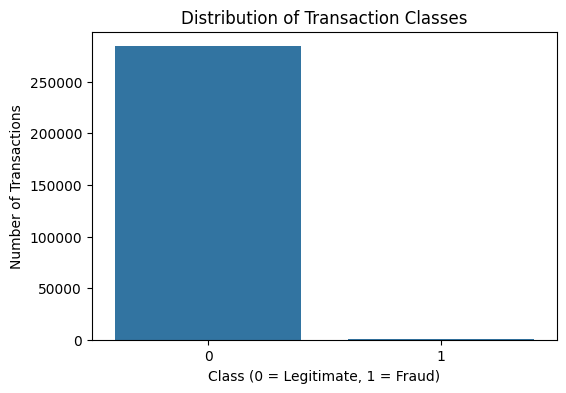

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Transaction Classes")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [10]:
legitimate = (df["Class"] == 0).sum()
fraud = (df["Class"] == 1).sum()
total = len(df)

print(f"Total transactions     : {total:,}")
print(f"Legitimate transactions: {legitimate:,}")
print(f"Fraudulent transactions: {fraud:,}")

print(f"\nLegitimate percentage: {legitimate / total * 100:.4f}%")
print(f"Fraud percentage     : {fraud / total * 100:.4f}%")

Total transactions     : 284,807
Legitimate transactions: 284,315
Fraudulent transactions: 492

Legitimate percentage: 99.8273%
Fraud percentage     : 0.1727%


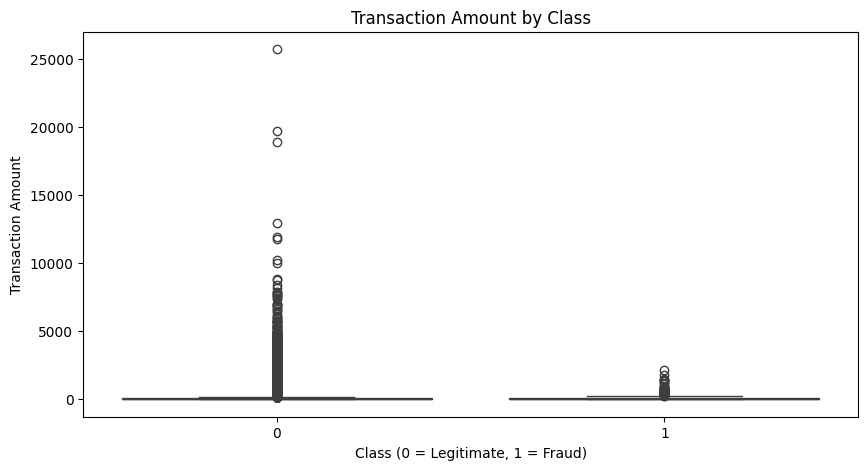

In [11]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

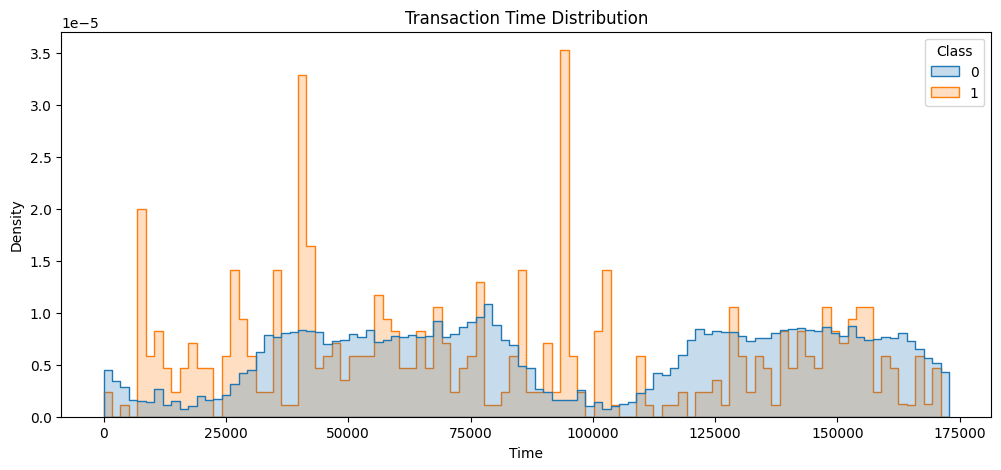

In [12]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Density")

plt.show()

In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


## Stage 2 — Data Preprocessing

Create a stratified train/test split, remove `Time` from the modeling features, standardize `Amount`, and establish a naive all-legitimate baseline.

**Why this matters:** with only 0.1727% fraud, accuracy can be misleading; PR-AUC, recall, precision, and F1 are more informative.

In [14]:
# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

Feature shape: (284807, 30)
Target shape : (284807,)


In [15]:
X = X.drop("Time", axis=1)

print("Shape after dropping Time:", X.shape)

Shape after dropping Time: (284807, 29)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (227845, 29)
Testing set : (56962, 29)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["Amount"] = scaler.fit_transform(
    X_train[["Amount"]]
)

X_test["Amount"] = scaler.transform(
    X_test[["Amount"]]
)

In [18]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test :", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test : 0


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict every transaction as legitimate
y_pred_naive = np.zeros(len(y_test), dtype=int)

print("Accuracy :", accuracy_score(y_test, y_pred_naive))
print("Precision:", precision_score(y_test, y_pred_naive, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_naive, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred_naive, zero_division=0))

Accuracy : 0.9982795547909132
Precision: 0.0
Recall   : 0.0
F1-score : 0.0


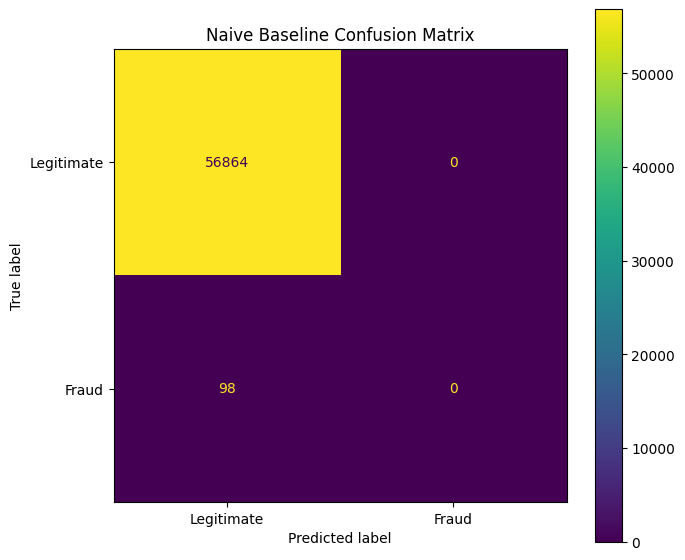

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Using the naive baseline predictions available in this stage
cm = confusion_matrix(y_test, y_pred_naive)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)
disp.plot(ax=ax)
plt.title("Naive Baseline Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
# Save processed datasets
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Preprocessed datasets saved successfully!")

Preprocessed datasets saved successfully!


In [23]:
print("=" * 50)
print("PREPROCESSING SUMMARY")
print("=" * 50)

print(f"Original dataset size : {df.shape}")
print(f"Training features     : {X_train.shape}")
print(f"Testing features      : {X_test.shape}")

print("\nFraud cases:")
print(f"Training: {y_train.sum()}")
print(f"Testing : {y_test.sum()}")

print("\nMissing values:")
print(f"Training: {X_train.isnull().sum().sum()}")
print(f"Testing : {X_test.isnull().sum().sum()}")

print("\nClass distribution:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

PREPROCESSING SUMMARY
Original dataset size : (284807, 31)
Training features     : (227845, 29)
Testing features      : (56962, 29)

Fraud cases:
Training: 394
Testing : 98

Missing values:
Training: 0
Testing : 0

Class distribution:
Class
0    99.827075
1     0.172925
Name: proportion, dtype: float64


## Stage 3 — Decision Tree Baseline

Train two simple baselines:

- Standard Decision Tree
- Class-weighted Decision Tree

Both are evaluated with Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC.

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Decision Tree and evaluation metrics imported!")

Decision Tree and evaluation metrics imported!


In [25]:
dt_baseline = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

dt_baseline.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [26]:
y_pred_dt = dt_baseline.predict(X_test)

# Probability of the fraud class
y_prob_dt = dt_baseline.predict_proba(X_test)[:, 1]

print("Predictions generated!")

Predictions generated!


In [27]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

    return results

In [28]:
dt_result = evaluate_model(
    "Decision Tree",
    y_test,
    y_pred_dt,
    y_prob_dt
)

dt_result

{'Model': 'Decision Tree',
 'Accuracy': 0.9991573329588147,
 'Precision': 0.7551020408163265,
 'Recall': 0.7551020408163265,
 'F1': 0.7551020408163265,
 'ROC-AUC': np.float64(0.8773399905826146),
 'PR-AUC': np.float64(0.5706004255655739)}

In [29]:
dt_balanced = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dt_balanced.fit(X_train, y_train)

print("Class-weighted Decision Tree trained!")

Class-weighted Decision Tree trained!


In [30]:
y_pred_dt_balanced = dt_balanced.predict(X_test)

y_prob_dt_balanced = dt_balanced.predict_proba(X_test)[:, 1]

In [31]:
dt_balanced_result = evaluate_model(
    "Decision Tree (Balanced)",
    y_test,
    y_pred_dt_balanced,
    y_prob_dt_balanced
)

dt_balanced_result

{'Model': 'Decision Tree (Balanced)',
 'Accuracy': 0.9989993328885924,
 'Precision': 0.7070707070707071,
 'Recall': 0.7142857142857143,
 'F1': 0.7106598984771574,
 'ROC-AUC': np.float64(0.8568878627703193),
 'PR-AUC': np.float64(0.5055420608245299)}

In [32]:
results = []

results.append(dt_result)
results.append(dt_balanced_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542


## Stage 4 — Random Forest

Evaluate standard and class-weighted Random Forest models. The goal is to test whether bagging and class weighting improve minority-class detection over a single tree.

In [33]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully!")

Random Forest imported successfully!


In [34]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [35]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [36]:
rf_result = evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

rf_result

{'Model': 'Random Forest',
 'Accuracy': 0.9996137776061234,
 'Precision': 0.9418604651162791,
 'Recall': 0.826530612244898,
 'F1': 0.8804347826086957,
 'ROC-AUC': np.float64(0.9520658133118188),
 'PR-AUC': np.float64(0.8741467508762261)}

In [37]:
results.append(rf_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147


In [38]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

print("Balanced Random Forest trained successfully!")

Balanced Random Forest trained successfully!


In [39]:
y_pred_rf_balanced = rf_balanced.predict(X_test)

y_prob_rf_balanced = rf_balanced.predict_proba(X_test)[:, 1]

In [40]:
rf_balanced_result = evaluate_model(
    "Random Forest (Balanced)",
    y_test,
    y_pred_rf_balanced,
    y_prob_rf_balanced
)

rf_balanced_result

{'Model': 'Random Forest (Balanced)',
 'Accuracy': 0.9995259997893332,
 'Precision': 0.961038961038961,
 'Recall': 0.7551020408163265,
 'F1': 0.8457142857142858,
 'ROC-AUC': np.float64(0.9571737758834541),
 'PR-AUC': np.float64(0.8453774590837698)}

In [41]:
results.append(rf_balanced_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377


## Stage 5 — Extra Trees

Evaluate standard and class-weighted Extra Trees. Extra Trees introduces additional randomization in tree construction and provides a strong candidate for highly imbalanced tabular classification.

In [42]:
from sklearn.ensemble import ExtraTreesClassifier

print("Extra Trees imported successfully!")

Extra Trees imported successfully!


In [43]:
extra_trees = ExtraTreesClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

extra_trees.fit(X_train, y_train)

print("Extra Trees trained successfully!")

Extra Trees trained successfully!


In [44]:
y_pred_et = extra_trees.predict(X_test)

y_prob_et = extra_trees.predict_proba(X_test)[:, 1]

print("Extra Trees predictions generated!")

Extra Trees predictions generated!


In [45]:
et_result = evaluate_model(
    "Extra Trees",
    y_test,
    y_pred_et,
    y_prob_et
)

et_result

{'Model': 'Extra Trees',
 'Accuracy': 0.9996313331694814,
 'Precision': 0.9425287356321839,
 'Recall': 0.8367346938775511,
 'F1': 0.8864864864864865,
 'ROC-AUC': np.float64(0.9670685803865723),
 'PR-AUC': np.float64(0.8819071162429364)}

In [46]:
results.append(et_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907


In [49]:
extra_trees_balanced = ExtraTreesClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

extra_trees_balanced.fit(X_train, y_train)

print("Balanced Extra Trees trained successfully!")

Balanced Extra Trees trained successfully!


In [50]:
y_pred_et_balanced = extra_trees_balanced.predict(X_test)

y_prob_et_balanced = (
    extra_trees_balanced.predict_proba(X_test)[:, 1]
)

In [51]:
et_balanced_result = evaluate_model(
    "Extra Trees (Balanced)",
    y_test,
    y_pred_et_balanced,
    y_prob_et_balanced
)

et_balanced_result

{'Model': 'Extra Trees (Balanced)',
 'Accuracy': 0.9996137776061234,
 'Precision': 0.9523809523809523,
 'Recall': 0.8163265306122449,
 'F1': 0.8791208791208791,
 'ROC-AUC': np.float64(0.9623625793874107),
 'PR-AUC': np.float64(0.8821188653163627)}

In [52]:
results.append(et_balanced_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907
5,Extra Trees (Balanced),0.999614,0.952381,0.816327,0.879121,0.962363,0.882119


## Stage 6 — AdaBoost

Evaluate standard and class-balanced AdaBoost models. AdaBoost sequentially emphasizes observations that previous weak learners classify poorly.

In [53]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

print("AdaBoost imported successfully!")

AdaBoost imported successfully!


In [54]:
weak_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=RANDOM_STATE
)

print("Weak learner created!")

Weak learner created!


In [55]:
ada = AdaBoostClassifier(
    estimator=weak_tree,
    n_estimators=200,
    learning_rate=0.5,
    random_state=RANDOM_STATE
)

ada.fit(X_train, y_train)

print("AdaBoost trained successfully!")

AdaBoost trained successfully!


In [56]:
y_pred_ada = ada.predict(X_test)

y_prob_ada = ada.predict_proba(X_test)[:, 1]

print("AdaBoost predictions generated!")

AdaBoost predictions generated!


In [57]:
ada_result = evaluate_model(
    "AdaBoost",
    y_test,
    y_pred_ada,
    y_prob_ada
)

ada_result

{'Model': 'AdaBoost',
 'Accuracy': 0.9990695551420246,
 'Precision': 0.7528089887640449,
 'Recall': 0.6836734693877551,
 'F1': 0.7165775401069518,
 'ROC-AUC': np.float64(0.9781831767597304),
 'PR-AUC': np.float64(0.7630635037159471)}

In [58]:
results.append(ada_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907
5,Extra Trees (Balanced),0.999614,0.952381,0.816327,0.879121,0.962363,0.882119
6,AdaBoost,0.999070,0.752809,0.683673,0.716578,0.978183,0.763064


In [59]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

print("Sample weights created!")
print("Minimum weight:", sample_weights.min())
print("Maximum weight:", sample_weights.max())

Sample weights created!
Minimum weight: 0.5008661206149896
Maximum weight: 289.14340101522845


In [60]:
weak_tree_balanced = DecisionTreeClassifier(
    max_depth=1,
    random_state=RANDOM_STATE
)

In [61]:
ada_balanced = AdaBoostClassifier(
    estimator=weak_tree_balanced,
    n_estimators=200,
    learning_rate=0.5,
    random_state=RANDOM_STATE
)

ada_balanced.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("Balanced AdaBoost trained successfully!")

Balanced AdaBoost trained successfully!


In [62]:
y_pred_ada_balanced = ada_balanced.predict(X_test)

y_prob_ada_balanced = (
    ada_balanced.predict_proba(X_test)[:, 1]
)

print("Balanced AdaBoost predictions generated!")

Balanced AdaBoost predictions generated!


In [63]:
ada_balanced_result = evaluate_model(
    "AdaBoost (Balanced)",
    y_test,
    y_pred_ada_balanced,
    y_prob_ada_balanced
)

ada_balanced_result

{'Model': 'AdaBoost (Balanced)',
 'Accuracy': 0.9786524349566378,
 'Precision': 0.06800618238021638,
 'Recall': 0.8979591836734694,
 'F1': 0.12643678160919541,
 'ROC-AUC': np.float64(0.9746063468296716),
 'PR-AUC': np.float64(0.7710473328856063)}

In [64]:
results.append(ada_balanced_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907
5,Extra Trees (Balanced),0.999614,0.952381,0.816327,0.879121,0.962363,0.882119
6,AdaBoost,0.999070,0.752809,0.683673,0.716578,0.978183,0.763064
7,AdaBoost (Balanced),0.978652,0.068006,0.897959,0.126437,0.974606,0.771047


## Stage 7 — Gradient Boosting

Evaluate standard and class-balanced Gradient Boosting models. Each successive tree is trained to improve the current ensemble's errors.

In [65]:
from sklearn.ensemble import GradientBoostingClassifier

print("Gradient Boosting imported successfully!")

Gradient Boosting imported successfully!


In [66]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb.fit(X_train, y_train)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [67]:
y_pred_gb = gb.predict(X_test)

y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting predictions generated!")

Gradient Boosting predictions generated!


In [68]:
gb_result = evaluate_model(
    "Gradient Boosting",
    y_test,
    y_pred_gb,
    y_prob_gb
)

gb_result

{'Model': 'Gradient Boosting',
 'Accuracy': 0.9983146659176293,
 'Precision': 0.5294117647058824,
 'Recall': 0.1836734693877551,
 'F1': 0.2727272727272727,
 'ROC-AUC': np.float64(0.3468859283302516),
 'PR-AUC': np.float64(0.15665434666029338)}

In [69]:
results.append(gb_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907
5,Extra Trees (Balanced),0.999614,0.952381,0.816327,0.879121,0.962363,0.882119
6,AdaBoost,0.999070,0.752809,0.683673,0.716578,0.978183,0.763064
7,AdaBoost (Balanced),0.978652,0.068006,0.897959,0.126437,0.974606,0.771047
8,Gradient Boosting,0.998315,0.529412,0.183673,0.272727,0.346886,0.156654


In [70]:
gb_balanced = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_balanced.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

print("Balanced Gradient Boosting trained successfully!")

Balanced Gradient Boosting trained successfully!


In [71]:
y_pred_gb_balanced = gb_balanced.predict(X_test)

y_prob_gb_balanced = (
    gb_balanced.predict_proba(X_test)[:, 1]
)

print("Balanced Gradient Boosting predictions generated!")

Balanced Gradient Boosting predictions generated!


In [72]:
gb_balanced_result = evaluate_model(
    "Gradient Boosting (Balanced)",
    y_test,
    y_pred_gb_balanced,
    y_prob_gb_balanced
)

gb_balanced_result

{'Model': 'Gradient Boosting (Balanced)',
 'Accuracy': 0.99252133000948,
 'Precision': 0.1746031746031746,
 'Recall': 0.8979591836734694,
 'F1': 0.292358803986711,
 'ROC-AUC': np.float64(0.9772811857579272),
 'PR-AUC': np.float64(0.7150106522485308)}

In [73]:
results.append(gb_balanced_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907
5,Extra Trees (Balanced),0.999614,0.952381,0.816327,0.879121,0.962363,0.882119
6,AdaBoost,0.999070,0.752809,0.683673,0.716578,0.978183,0.763064
7,AdaBoost (Balanced),0.978652,0.068006,0.897959,0.126437,0.974606,0.771047
8,Gradient Boosting,0.998315,0.529412,0.183673,0.272727,0.346886,0.156654
9,Gradient Boosting (Balanced),0.992521,0.174603,0.897959,0.292359,0.977281,0.715011


## Stage 8 — XGBoost

Train XGBoost with `scale_pos_weight` to explicitly account for the severe class imbalance. XGBoost serves as the optimized gradient-boosting benchmark.

In [74]:
!pip install -q xgboost

In [75]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [76]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count # imbalance ratio

print("Legitimate transactions:", negative_count)
print("Fraud transactions     :", positive_count)
print("scale_pos_weight       :", scale_pos_weight)

Legitimate transactions: 227451
Fraud transactions     : 394
scale_pos_weight       : 577.2868020304569


In [77]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [78]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated!")

XGBoost predictions generated!


In [79]:
xgb_result = evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

xgb_result

{'Model': 'XGBoost',
 'Accuracy': 0.9971559987359995,
 'Precision': 0.36554621848739494,
 'Recall': 0.8877551020408163,
 'F1': 0.5178571428571429,
 'ROC-AUC': np.float64(0.9838641140192712),
 'PR-AUC': np.float64(0.8230205232616756)}

In [80]:
results.append(xgb_result)

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907
5,Extra Trees (Balanced),0.999614,0.952381,0.816327,0.879121,0.962363,0.882119
6,AdaBoost,0.999070,0.752809,0.683673,0.716578,0.978183,0.763064
7,AdaBoost (Balanced),0.978652,0.068006,0.897959,0.126437,0.974606,0.771047
8,Gradient Boosting,0.998315,0.529412,0.183673,0.272727,0.346886,0.156654
9,Gradient Boosting (Balanced),0.992521,0.174603,0.897959,0.292359,0.977281,0.715011


## Stage 9 — Model Comparison & Threshold Optimization

Compare all candidate models using **PR-AUC, F1, Recall, Precision, and ROC-AUC**. Because the fraud class is rare, PR-AUC is the primary ranking criterion.

The strongest candidate is then evaluated across decision thresholds to find a better precision–recall operating point than the default 0.5 threshold.

In [81]:
leaderboard = results_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

leaderboard

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Extra Trees (Balanced),0.999614,0.952381,0.816327,0.879121,0.962363,0.882119
1,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,XGBoost,0.997156,0.365546,0.887755,0.517857,0.983864,0.823021
5,AdaBoost (Balanced),0.978652,0.068006,0.897959,0.126437,0.974606,0.771047
6,AdaBoost,0.999070,0.752809,0.683673,0.716578,0.978183,0.763064
7,Gradient Boosting (Balanced),0.992521,0.174603,0.897959,0.292359,0.977281,0.715011
8,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
9,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542


In [82]:
leaderboard_display = leaderboard.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

leaderboard_display[metric_columns] = (
    leaderboard_display[metric_columns].round(4)
)

leaderboard_display

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Extra Trees (Balanced),0.9996,0.9524,0.8163,0.8791,0.9624,0.8821
1,Extra Trees,0.9996,0.9425,0.8367,0.8865,0.9671,0.8819
2,Random Forest,0.9996,0.9419,0.8265,0.8804,0.9521,0.8741
3,Random Forest (Balanced),0.9995,0.9610,0.7551,0.8457,0.9572,0.8454
4,XGBoost,0.9972,0.3655,0.8878,0.5179,0.9839,0.8230
5,AdaBoost (Balanced),0.9787,0.0680,0.8980,0.1264,0.9746,0.7710
6,AdaBoost,0.9991,0.7528,0.6837,0.7166,0.9782,0.7631
7,Gradient Boosting (Balanced),0.9925,0.1746,0.8980,0.2924,0.9773,0.7150
8,Decision Tree,0.9992,0.7551,0.7551,0.7551,0.8773,0.5706
9,Decision Tree (Balanced),0.9990,0.7071,0.7143,0.7107,0.8569,0.5055


In [83]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907
5,Extra Trees (Balanced),0.999614,0.952381,0.816327,0.879121,0.962363,0.882119
6,AdaBoost,0.999070,0.752809,0.683673,0.716578,0.978183,0.763064
7,AdaBoost (Balanced),0.978652,0.068006,0.897959,0.126437,0.974606,0.771047
8,Gradient Boosting,0.998315,0.529412,0.183673,0.272727,0.346886,0.156654
9,Gradient Boosting (Balanced),0.992521,0.174603,0.897959,0.292359,0.977281,0.715011


In [84]:
comparison_df = results_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

comparison_df[metrics] = comparison_df[metrics].round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.9992,0.7551,0.7551,0.7551,0.8773,0.5706
1,Decision Tree (Balanced),0.9990,0.7071,0.7143,0.7107,0.8569,0.5055
2,Random Forest,0.9996,0.9419,0.8265,0.8804,0.9521,0.8741
3,Random Forest (Balanced),0.9995,0.9610,0.7551,0.8457,0.9572,0.8454
4,Extra Trees,0.9996,0.9425,0.8367,0.8865,0.9671,0.8819
5,Extra Trees (Balanced),0.9996,0.9524,0.8163,0.8791,0.9624,0.8821
6,AdaBoost,0.9991,0.7528,0.6837,0.7166,0.9782,0.7631
7,AdaBoost (Balanced),0.9787,0.0680,0.8980,0.1264,0.9746,0.7710
8,Gradient Boosting,0.9983,0.5294,0.1837,0.2727,0.3469,0.1567
9,Gradient Boosting (Balanced),0.9925,0.1746,0.8980,0.2924,0.9773,0.7150


In [86]:
leaderboard[
    [
        "Model",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC",
        "PR-AUC"
    ]
]

,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Extra Trees (Balanced),0.952381,0.816327,0.879121,0.962363,0.882119
1,Extra Trees,0.942529,0.836735,0.886486,0.967069,0.881907
2,Random Forest,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.961039,0.755102,0.845714,0.957174,0.845377
4,XGBoost,0.365546,0.887755,0.517857,0.983864,0.823021
5,AdaBoost (Balanced),0.068006,0.897959,0.126437,0.974606,0.771047
6,AdaBoost,0.752809,0.683673,0.716578,0.978183,0.763064
7,Gradient Boosting (Balanced),0.174603,0.897959,0.292359,0.977281,0.715011
8,Decision Tree,0.755102,0.755102,0.755102,0.877340,0.570600
9,Decision Tree (Balanced),0.707071,0.714286,0.710660,0.856888,0.505542


In [87]:
best_pr_auc_model = comparison_df.loc[
    comparison_df["PR-AUC"].idxmax()
]

print("Best model by PR-AUC:")
print(best_pr_auc_model)

Best model by PR-AUC:
Model        Extra Trees (Balanced)
Accuracy                     0.9996
Precision                    0.9524
Recall                       0.8163
F1                           0.8791
ROC-AUC                      0.9624
PR-AUC                       0.8821
Name: 5, dtype: object


In [88]:
best_model_name = best_pr_auc_model["Model"]

print("Selected candidate:", best_model_name)

Selected candidate: Extra Trees (Balanced)


In [89]:
probability_predictions = {
    "Decision Tree": y_prob_dt,
    "Decision Tree (Balanced)": y_prob_dt_balanced,
    "Random Forest": y_prob_rf,
    "Random Forest (Balanced)": y_prob_rf_balanced,
    "Extra Trees": y_prob_et,
    "Extra Trees (Balanced)": y_prob_et_balanced,
    "AdaBoost": y_prob_ada,
    "AdaBoost (Balanced)": y_prob_ada_balanced,
    "Gradient Boosting": y_prob_gb,
    "Gradient Boosting (Balanced)": y_prob_gb_balanced,
    "XGBoost": y_prob_xgb
}

best_probabilities = probability_predictions[
    best_model_name
]

In [90]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    best_probabilities
)

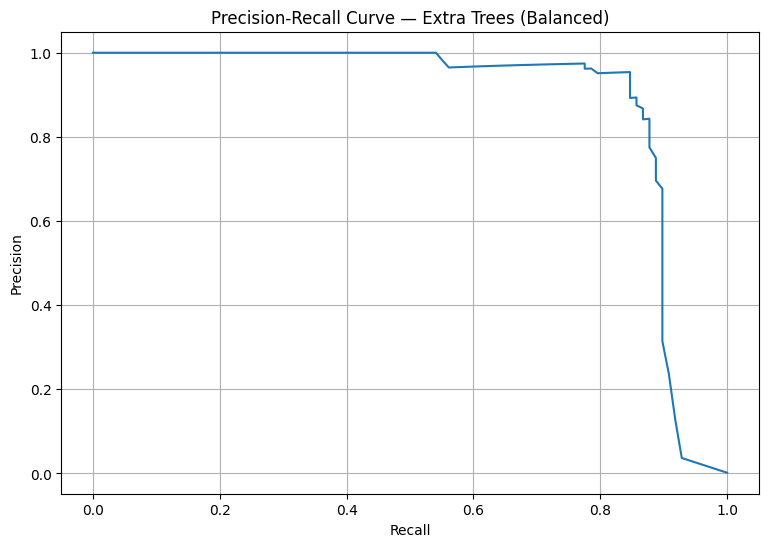

In [91]:
plt.figure(figsize=(9, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision-Recall Curve — {best_model_name}"
)

plt.grid(True)

plt.show()

In [92]:
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-12)
)

best_threshold_index = np.argmax(f1_scores)

best_threshold = thresholds[best_threshold_index]
best_threshold_f1 = f1_scores[best_threshold_index]

print("Best threshold:", best_threshold)
print("Best F1-score :", best_threshold_f1)

Best threshold: 0.445
Best F1-score : 0.8972972972967991


In [93]:
y_pred_threshold = (
    best_probabilities >= best_threshold
).astype(int)

In [94]:
threshold_result = evaluate_model(
    f"{best_model_name} (Optimized Threshold)",
    y_test,
    y_pred_threshold,
    best_probabilities
)

threshold_result

{'Model': 'Extra Trees (Balanced) (Optimized Threshold)',
 'Accuracy': 0.9996664442961974,
 'Precision': 0.9540229885057471,
 'Recall': 0.8469387755102041,
 'F1': 0.8972972972972973,
 'ROC-AUC': np.float64(0.9623625793874107),
 'PR-AUC': np.float64(0.8821188653163627)}

In [95]:
threshold_values = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

threshold_results = []

for threshold in threshold_values:

    predictions = (
        best_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.05,0.606897,0.897959,0.724280
1,0.10,0.781818,0.877551,0.826923
2,0.15,0.843137,0.877551,0.860000
3,0.20,0.867347,0.867347,0.867347
4,0.25,0.892473,0.846939,0.869110
5,0.30,0.932584,0.846939,0.887701
6,0.40,0.954023,0.846939,0.897297
7,0.50,0.952381,0.816327,0.879121
8,0.60,0.972973,0.734694,0.837209
9,0.70,0.972222,0.714286,0.823529


In [96]:
results_with_threshold = pd.concat(
    [
        results_df,
        pd.DataFrame([threshold_result])
    ],
    ignore_index=True
)

results_with_threshold

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Decision Tree,0.999157,0.755102,0.755102,0.755102,0.877340,0.570600
1,Decision Tree (Balanced),0.998999,0.707071,0.714286,0.710660,0.856888,0.505542
2,Random Forest,0.999614,0.941860,0.826531,0.880435,0.952066,0.874147
3,Random Forest (Balanced),0.999526,0.961039,0.755102,0.845714,0.957174,0.845377
4,Extra Trees,0.999631,0.942529,0.836735,0.886486,0.967069,0.881907
5,Extra Trees (Balanced),0.999614,0.952381,0.816327,0.879121,0.962363,0.882119
6,AdaBoost,0.999070,0.752809,0.683673,0.716578,0.978183,0.763064
7,AdaBoost (Balanced),0.978652,0.068006,0.897959,0.126437,0.974606,0.771047
8,Gradient Boosting,0.998315,0.529412,0.183673,0.272727,0.346886,0.156654
9,Gradient Boosting (Balanced),0.992521,0.174603,0.897959,0.292359,0.977281,0.715011


In [97]:
# Get the default F1 score of the selected best model
default_model_result = comparison_df[
    comparison_df["Model"] == best_model_name
].iloc[0]

default_f1 = default_model_result["F1"]

# Get the optimized-threshold F1 score
optimized_f1 = threshold_result["F1"]

# Calculate improvement
f1_improvement = optimized_f1 - default_f1

print("Selected Model :", best_model_name)
print("Default F1     :", round(default_f1, 4))
print("Optimized F1   :", round(optimized_f1, 4))
print("Improvement     :", round(f1_improvement, 4))

Selected Model : Extra Trees (Balanced)
Default F1     : 0.8791
Optimized F1   : 0.8973
Improvement     : 0.0182


In [98]:
# Get the default Recall score of the selected best model
default_model_result = comparison_df[
    comparison_df["Model"] == best_model_name
].iloc[0]

default_recall = default_model_result["Recall"]
optimized_recall = threshold_result["Recall"]

print("Default Recall   :", round(default_recall, 4))
print("Optimized Recall :", round(optimized_recall, 4))
print(
    "Recall change    :",
    round(optimized_recall - default_recall, 4)
)

Default Recall   : 0.8163
Optimized Recall : 0.8469
Recall change    : 0.0306


In [109]:
threshold_info = {
    "Model": best_model_name,
    "Best_Threshold": best_threshold,
    "Best_F1": best_threshold_f1
}

pd.DataFrame([threshold_info]).to_csv(
    "optimized_threshold.csv",
    index=False
)

print("Threshold information saved!")

Threshold information saved!


In [110]:
results_with_threshold.to_csv(
    "complete_model_results.csv",
    index=False
)

print("Complete model comparison saved!")

Complete model comparison saved!


## Stage 10 — Validation-Based Final Model Selection

A validation split is created **inside the original training set** so the test set remains untouched during model selection.

Candidate models are compared on the validation set using:

1. PR-AUC
2. F1-score
3. Recall

The best validation model is retrained on the full training data, and its threshold is selected using validation predictions before one final evaluation on the held-out test set.

In [111]:
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Training subset:", X_train_sub.shape)
print("Validation set :", X_val.shape)
print("Final test set :", X_test.shape)

print("\nFraud distribution:")
print("Train:", y_train_sub.value_counts().to_dict())
print("Validation:", y_val.value_counts().to_dict())
print("Test:", y_test.value_counts().to_dict())

Training subset: (182276, 29)
Validation set : (45569, 29)
Final test set : (56962, 29)

Fraud distribution:
Train: {0: 181961, 1: 315}
Validation: {0: 45490, 1: 79}
Test: {0: 56864, 1: 98}


In [112]:
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)
import xgboost as xgb

candidate_models = {}
candidate_predictions = {}
candidate_results = []

In [113]:
rf_val = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_val.fit(X_train_sub, y_train_sub)

rf_val_prob = rf_val.predict_proba(X_val)[:, 1]
rf_val_pred = (rf_val_prob >= 0.5).astype(int)

rf_val_result = evaluate_model(
    "Random Forest",
    y_val,
    rf_val_pred,
    rf_val_prob
)

candidate_models["Random Forest"] = rf_val
candidate_predictions["Random Forest"] = rf_val_prob
candidate_results.append(rf_val_result)

print(rf_val_result)

{'Model': 'Random Forest', 'Accuracy': 0.9994952709078541, 'Precision': 0.9375, 'Recall': 0.759493670886076, 'F1': 0.8391608391608392, 'ROC-AUC': np.float64(0.933914534005248), 'PR-AUC': np.float64(0.8177323034551387)}


In [114]:
et_val = ExtraTreesClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

et_val.fit(X_train_sub, y_train_sub)

et_val_prob = et_val.predict_proba(X_val)[:, 1]
et_val_pred = (et_val_prob >= 0.5).astype(int)

et_val_result = evaluate_model(
    "Extra Trees",
    y_val,
    et_val_pred,
    et_val_prob
)

candidate_models["Extra Trees"] = et_val
candidate_predictions["Extra Trees"] = et_val_prob
candidate_results.append(et_val_result)

print(et_val_result)

{'Model': 'Extra Trees', 'Accuracy': 0.9994733261647173, 'Precision': 0.9508196721311475, 'Recall': 0.7341772151898734, 'F1': 0.8285714285714286, 'ROC-AUC': np.float64(0.9468540867237478), 'PR-AUC': np.float64(0.830214717856246)}


In [115]:
gb_val = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE
)

gb_val.fit(X_train_sub, y_train_sub)

gb_val_prob = gb_val.predict_proba(X_val)[:, 1]
gb_val_pred = (gb_val_prob >= 0.5).astype(int)

gb_val_result = evaluate_model(
    "Gradient Boosting",
    y_val,
    gb_val_pred,
    gb_val_prob
)

candidate_models["Gradient Boosting"] = gb_val
candidate_predictions["Gradient Boosting"] = gb_val_prob
candidate_results.append(gb_val_result)

print(gb_val_result)

{'Model': 'Gradient Boosting', 'Accuracy': 0.9989466523294345, 'Precision': 0.7924528301886793, 'Recall': 0.5316455696202531, 'F1': 0.6363636363636364, 'ROC-AUC': np.float64(0.7908707157784017), 'PR-AUC': np.float64(0.5444392579151722)}


In [116]:
negative_count_val = (y_train_sub == 0).sum()
positive_count_val = (y_train_sub == 1).sum()

scale_pos_weight_val = negative_count_val / positive_count_val

print("Negative samples:", negative_count_val)
print("Positive samples:", positive_count_val)
print("scale_pos_weight:", round(scale_pos_weight_val, 2))

Negative samples: 181961
Positive samples: 315
scale_pos_weight: 577.65


In [117]:
xgb_val = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_val,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_val.fit(X_train_sub, y_train_sub)

xgb_val_prob = xgb_val.predict_proba(X_val)[:, 1]
xgb_val_pred = (xgb_val_prob >= 0.5).astype(int)

xgb_val_result = evaluate_model(
    "XGBoost",
    y_val,
    xgb_val_pred,
    xgb_val_prob
)

candidate_models["XGBoost"] = xgb_val
candidate_predictions["XGBoost"] = xgb_val_prob
candidate_results.append(xgb_val_result)

print(xgb_val_result)

{'Model': 'XGBoost', 'Accuracy': 0.9982663652921943, 'Precision': 0.5, 'Recall': 0.810126582278481, 'F1': 0.6183574879227053, 'ROC-AUC': np.float64(0.9700663103032798), 'PR-AUC': np.float64(0.7649022888503677)}


In [118]:
validation_results_df = pd.DataFrame(candidate_results)

validation_results_df = validation_results_df.sort_values(
    by=["PR-AUC", "F1", "Recall"],
    ascending=False
).reset_index(drop=True)

validation_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Extra Trees,0.999473,0.950820,0.734177,0.828571,0.946854,0.830215
1,Random Forest,0.999495,0.937500,0.759494,0.839161,0.933915,0.817732
2,XGBoost,0.998266,0.500000,0.810127,0.618357,0.970066,0.764902
3,Gradient Boosting,0.998947,0.792453,0.531646,0.636364,0.790871,0.544439


In [119]:
validation_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Extra Trees,0.9995,0.9508,0.7342,0.8286,0.9469,0.8302
1,Random Forest,0.9995,0.9375,0.7595,0.8392,0.9339,0.8177
2,XGBoost,0.9983,0.5000,0.8101,0.6184,0.9701,0.7649
3,Gradient Boosting,0.9989,0.7925,0.5316,0.6364,0.7909,0.5444


In [120]:
best_validation_row = validation_results_df.iloc[0]

best_validation_model_name = best_validation_row["Model"]

best_validation_model = candidate_models[
    best_validation_model_name
]

best_validation_prob = candidate_predictions[
    best_validation_model_name
]

print("Best validation model:", best_validation_model_name)
print("Validation PR-AUC:", round(best_validation_row["PR-AUC"], 4))
print("Validation F1:", round(best_validation_row["F1"], 4))
print("Validation Recall:", round(best_validation_row["Recall"], 4))

Best validation model: Extra Trees
Validation PR-AUC: 0.8302
Validation F1: 0.8286
Validation Recall: 0.7342


In [121]:
from sklearn.metrics import precision_recall_curve

precision_val, recall_val, thresholds_val = precision_recall_curve(
    y_val,
    best_validation_prob
)

f1_val = (
    2 * precision_val[:-1] * recall_val[:-1]
    / (precision_val[:-1] + recall_val[:-1] + 1e-12)
)

best_threshold_index_val = np.argmax(f1_val)

best_threshold_val = thresholds_val[best_threshold_index_val]
best_f1_val = f1_val[best_threshold_index_val]

print("Best validation threshold:", round(best_threshold_val, 4))
print("Best validation F1:", round(best_f1_val, 4))

Best validation threshold: 0.425
Best validation F1: 0.8472


In [122]:
threshold_values = np.arange(0.05, 0.96, 0.05)

threshold_results_val = []

for threshold in threshold_values:

    y_pred_temp = (
        best_validation_prob >= threshold
    ).astype(int)

    threshold_results_val.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val, y_pred_temp, zero_division=0
        ),
        "Recall": recall_score(
            y_val, y_pred_temp, zero_division=0
        ),
        "F1": f1_score(
            y_val, y_pred_temp, zero_division=0
        )
    })

threshold_df_val = pd.DataFrame(threshold_results_val)

threshold_df_val.round(4)

,Threshold,Precision,Recall,F1
0,0.05,0.6373,0.8228,0.7182
1,0.10,0.8125,0.8228,0.8176
2,0.15,0.8205,0.8101,0.8153
3,0.20,0.8312,0.8101,0.8205
4,0.25,0.8421,0.8101,0.8258
5,0.30,0.8750,0.7975,0.8344
6,0.35,0.8986,0.7848,0.8378
7,0.40,0.9385,0.7722,0.8472
8,0.45,0.9524,0.7595,0.8451
9,0.50,0.9508,0.7342,0.8286


In [123]:
if best_validation_model_name == "XGBoost":

    negative_count_full = (y_train == 0).sum()
    positive_count_full = (y_train == 1).sum()

    scale_pos_weight_full = (
        negative_count_full / positive_count_full
    )

    final_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_full,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

elif best_validation_model_name == "Random Forest":

    final_model = RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

elif best_validation_model_name == "Extra Trees":

    final_model = ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

elif best_validation_model_name == "Gradient Boosting":

    final_model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE
    )

final_model.fit(X_train, y_train)

print("Final model trained:", best_validation_model_name)

Final model trained: Extra Trees


In [124]:
final_test_prob = final_model.predict_proba(X_test)[:, 1]

final_test_pred = (
    final_test_prob >= best_threshold_val
).astype(int)

final_result = evaluate_model(
    f"{best_validation_model_name} (Final)",
    y_test,
    final_test_pred,
    final_test_prob
)

final_result

{'Model': 'Extra Trees (Final)',
 'Accuracy': 0.9996488887328394,
 'Precision': 0.9431818181818182,
 'Recall': 0.8469387755102041,
 'F1': 0.8924731182795699,
 'ROC-AUC': np.float64(0.9670685803865723),
 'PR-AUC': np.float64(0.8819071162429364)}

In [125]:
final_result_df = pd.DataFrame([final_result])

final_result_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Extra Trees (Final),0.9996,0.9432,0.8469,0.8925,0.9671,0.8819


In [126]:
import joblib

joblib.dump(
    final_model,
    "final_fraud_detection_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


In [127]:
import json

final_model_config = {
    "model": best_validation_model_name,
    "threshold": float(best_threshold_val),
    "features": list(X_train.columns)
}

with open("final_model_config.json", "w") as f:
    json.dump(final_model_config, f, indent=4)

print("Final model configuration saved.")

Final model configuration saved.


In [128]:
final_result_df.to_csv(
    "final_model_results.csv",
    index=False
)

validation_results_df.to_csv(
    "validation_model_comparison.csv",
    index=False
)

threshold_df_val.to_csv(
    "validation_threshold_analysis.csv",
    index=False
)

print("All Step 10 results saved.")

All Step 10 results saved.


## Stage 11 — SHAP Explainability

Use SHAP to explain the final tree-based model at two levels:

- **Global:** which features contribute most to fraud predictions overall.
- **Local:** why a representative high-confidence fraud prediction was classified as fraudulent.

In [129]:
!pip install -q shap

In [130]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [131]:
# Use a manageable sample for SHAP analysis
SHAP_SAMPLE_SIZE = 2000

if len(X_test) > SHAP_SAMPLE_SIZE:
    X_shap = X_test.sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )
else:
    X_shap = X_test.copy()

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (2000, 29)


In [132]:
explainer = shap.TreeExplainer(final_model)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [133]:
shap_output = explainer(X_shap)

print("SHAP values calculated.")

SHAP values calculated.


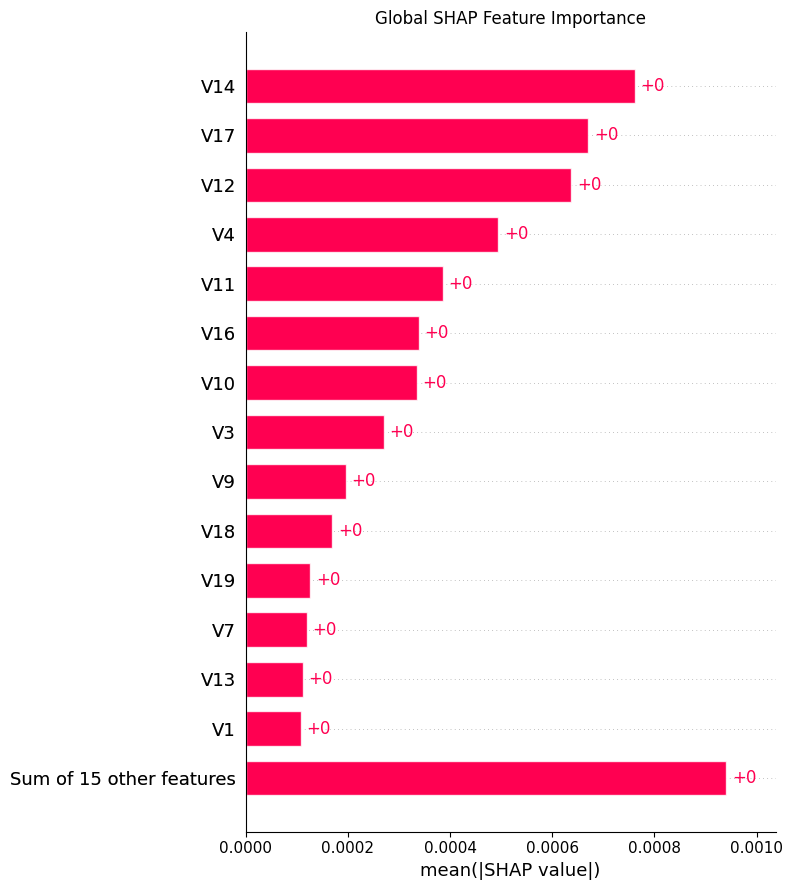

In [134]:
shap_values_for_class1 = shap_output.values[:, :, 1] # SHAP values for class 1
base_values_for_class1 = shap_output.base_values[:, 1] # Base value for class 1
data_for_explanation = shap_output.data # Original data

shap_explanation_for_class1 = shap.Explanation(
    values=shap_values_for_class1,
    base_values=base_values_for_class1,
    data=data_for_explanation,
    feature_names=X_shap.columns.tolist()
)

shap.plots.bar(
    shap_explanation_for_class1,
    max_display=15,
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.show()

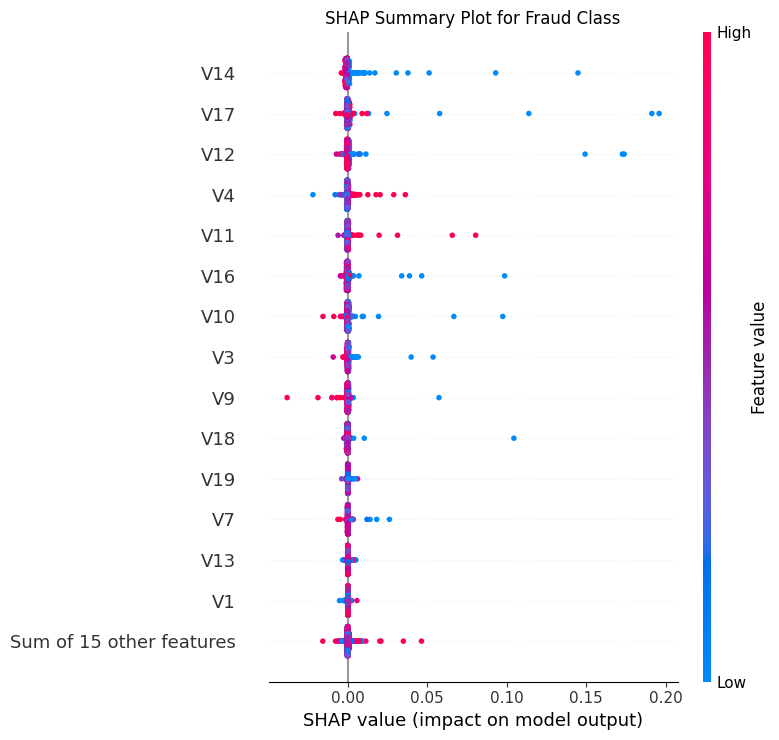

In [135]:
shap.plots.beeswarm(
    shap_explanation_for_class1, # Use the single-class explanation
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot for Fraud Class")
plt.tight_layout()
plt.show()

In [136]:
shap_values_array = shap_output.values

# Handle possible multi-output shape
if shap_values_array.ndim == 3:
    shap_values_array = shap_values_array[:, :, 1]

mean_abs_shap = np.abs(shap_values_array).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean |SHAP Value|": mean_abs_shap
})

shap_importance_df = shap_importance_df.sort_values(
    "Mean |SHAP Value|",
    ascending=False
).reset_index(drop=True)

shap_importance_df.head(15)

,Feature,Mean |SHAP Value|
0,V14,0.000761
1,V17,0.000670
2,V12,0.000638
3,V4,0.000495
4,V11,0.000386
5,V16,0.000338
6,V10,0.000335
7,V3,0.000270
8,V9,0.000196
9,V18,0.000170


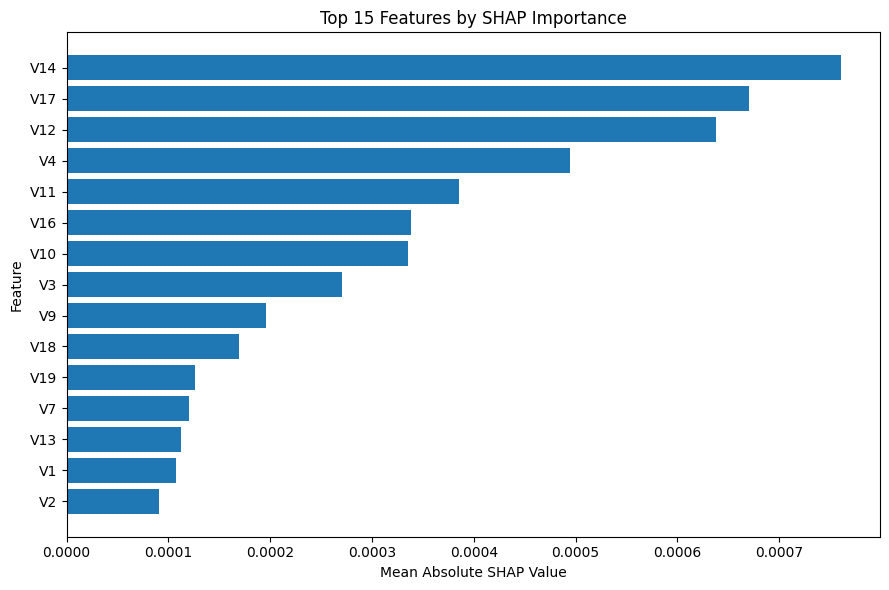

In [137]:
top_shap = shap_importance_df.head(15).sort_values(
    "Mean |SHAP Value|"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_shap["Feature"],
    top_shap["Mean |SHAP Value|"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 Features by SHAP Importance")

plt.tight_layout()
plt.show()

In [138]:
shap_sample_prob = final_model.predict_proba(X_shap)[:, 1]

fraud_candidates = np.where(
    shap_sample_prob >= best_threshold_val
)[0]

print(
    "Predicted fraud transactions in SHAP sample:",
    len(fraud_candidates)
)

Predicted fraud transactions in SHAP sample: 3


In [139]:
if len(fraud_candidates) > 0:

    fraud_idx = fraud_candidates[
        np.argmax(shap_sample_prob[fraud_candidates])
    ]

    print("Selected transaction index:", fraud_idx)
    print(
        "Fraud probability:",
        round(shap_sample_prob[fraud_idx], 6)
    )

else:
    print("No fraud transaction found in SHAP sample.")

Selected transaction index: 1109
Fraud probability: 0.975


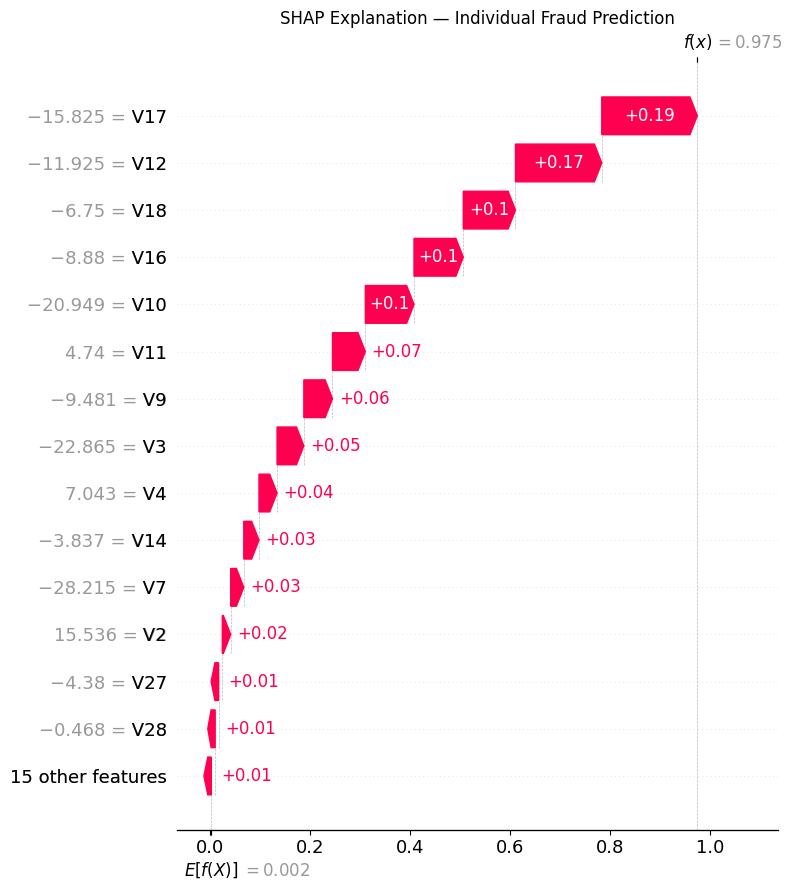

In [140]:
if len(fraud_candidates) > 0:

    shap.plots.waterfall(
        shap_explanation_for_class1[fraud_idx], # Use the single-class explanation for the specific fraud instance
        max_display=15,
        show=False
    )

    plt.title("SHAP Explanation — Individual Fraud Prediction")
    plt.tight_layout()
    plt.show()

In [141]:
if len(fraud_candidates) > 0:

    # Select SHAP values specifically for the 'fraud' class (class 1)
    fraud_shap_values = shap_output[fraud_idx].values[:, 1]

    fraud_explanation_df = pd.DataFrame({
        "Feature": X_shap.columns,
        "Feature Value": X_shap.iloc[fraud_idx].values,
        "SHAP Value": fraud_shap_values
    })

    fraud_explanation_df["Absolute SHAP"] = (
        fraud_explanation_df["SHAP Value"].abs()
    )

    fraud_explanation_df = fraud_explanation_df.sort_values(
        "Absolute SHAP",
        ascending=False
    ).reset_index(drop=True)

    fraud_explanation_df.head(15)

In [142]:
shap_importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved.")

SHAP feature importance saved.


In [143]:
if len(fraud_candidates) > 0:

    fraud_explanation_df.to_csv(
        "shap_fraud_transaction_explanation.csv",
        index=False
    )

    print("Individual fraud explanation saved.")

Individual fraud explanation saved.


In [144]:
print("=" * 60)
print("SHAP EXPLAINABILITY SUMMARY")
print("=" * 60)

print("\nFinal Model:", best_validation_model_name)

print(
    "\nTop 10 Most Important Features:"
)

for i, row in shap_importance_df.head(10).iterrows():

    print(
        f"{i+1}. {row['Feature']} "
        f"→ {row['Mean |SHAP Value|']:.6f}"
    )

SHAP EXPLAINABILITY SUMMARY

Final Model: Extra Trees

Top 10 Most Important Features:
1. V14 → 0.000761
2. V17 → 0.000670
3. V12 → 0.000638
4. V4 → 0.000495
5. V11 → 0.000386
6. V16 → 0.000338
7. V10 → 0.000335
8. V3 → 0.000270
9. V9 → 0.000196
10. V18 → 0.000170


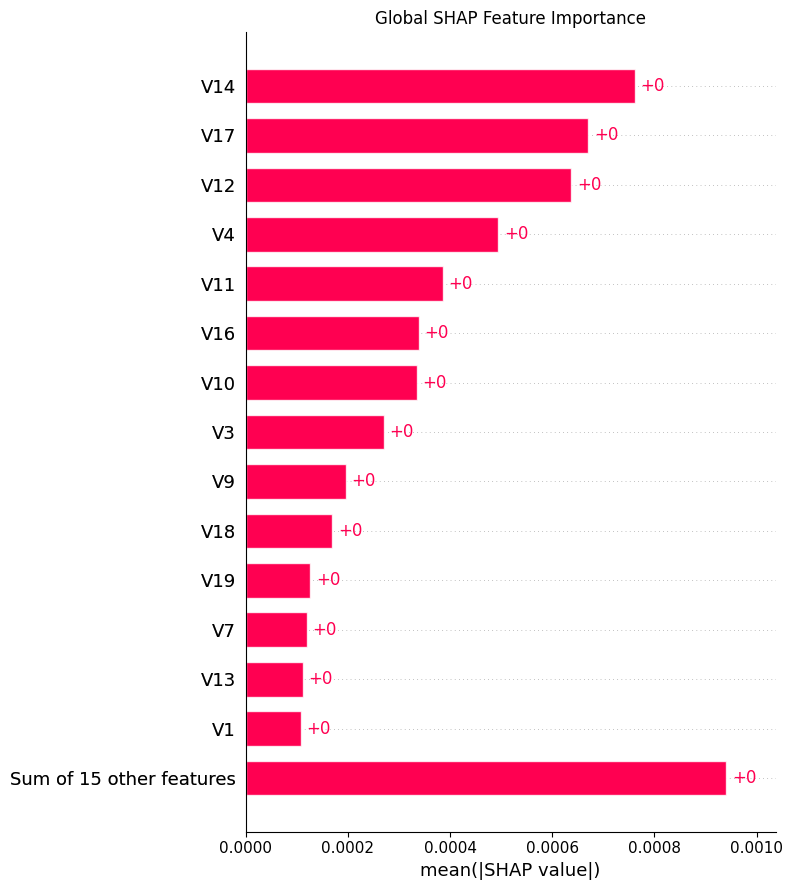

In [145]:
shap.plots.bar(
    shap_explanation_for_class1,
    max_display=15,
    show=False
)

plt.title("Global SHAP Feature Importance")
plt.tight_layout()

plt.savefig(
    "shap_global_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Stage 12 — Error Analysis

Analyze the final test predictions by separating true positives, true negatives, false positives, and false negatives.

Focus on:
- false-positive and false-negative rates,
- transactions close to the decision threshold,
- fraud-probability distributions,
- and the operational trade-off between missed fraud and unnecessary alerts.


In [146]:
error_analysis_df = X_test.copy()

error_analysis_df["Actual"] = y_test.values
error_analysis_df["Predicted"] = final_test_pred
error_analysis_df["Fraud_Probability"] = final_test_prob

def classify_prediction(row):
    if row["Actual"] == 1 and row["Predicted"] == 1:
        return "True Positive"
    elif row["Actual"] == 0 and row["Predicted"] == 0:
        return "True Negative"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "False Positive"
    else:
        return "False Negative"

error_analysis_df["Prediction_Type"] = (
    error_analysis_df.apply(classify_prediction, axis=1)
)

print("Error analysis dataset created.")
print(error_analysis_df.shape)

Error analysis dataset created.
(56962, 33)


In [147]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    final_test_pred
).ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 56859
False Positives: 5
False Negatives: 15
True Positives : 83


In [148]:
false_positive_rate = fp / (fp + tn)

false_negative_rate = fn / (fn + tp)

print("False Positive Rate :", round(false_positive_rate, 6))
print("False Negative Rate :", round(false_negative_rate, 6))

print("Precision            :", round(precision_score(
    y_test, final_test_pred, zero_division=0
), 6))

print("Recall               :", round(recall_score(
    y_test, final_test_pred, zero_division=0
), 6))

False Positive Rate : 8.8e-05
False Negative Rate : 0.153061
Precision            : 0.943182
Recall               : 0.846939


In [149]:
false_positives = error_analysis_df[
    (error_analysis_df["Actual"] == 0) &
    (error_analysis_df["Predicted"] == 1)
].copy()

print("Number of False Positives:", len(false_positives))

false_positives.head(10)

Number of False Positives: 5


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Actual,Predicted,Fraud_Probability,Prediction_Type
190263,-1.272117,1.827615,-3.810610,0.583759,-0.641242,-1.389043,-1.954054,1.173920,-2.053191,-3.345061,2.376404,-2.538052,-0.090454,-2.426168,-1.618648,-3.515944,-6.199008,-2.410606,0.760435,-0.027268,0.858998,0.858775,0.083079,0.741676,-0.173234,0.534870,0.183562,0.020316,-0.348658,0,1,0.590,False Positive
14920,-17.950631,11.067069,-20.742660,6.075531,-13.389765,-4.532888,-15.188146,12.101062,-4.026880,-9.017413,6.070650,-8.567865,-0.001900,-9.301233,0.019796,-7.352120,-13.923225,-4.988304,1.347656,1.712909,1.797134,-1.275675,-0.705046,0.102040,1.177477,-0.238730,1.554463,0.547948,-0.347701,0,1,0.850,False Positive
153398,-2.690251,1.465266,-0.691844,4.322855,-1.086880,0.063585,-2.966872,-0.059646,-0.090827,-1.291980,2.969599,-6.835634,-0.226037,-2.484695,-2.207474,-1.883016,-6.675449,-1.273625,-1.161245,-0.632750,1.211390,0.259112,0.610188,-0.119366,0.028077,-0.044074,0.005614,0.557189,-0.351689,0,1,0.580,False Positive
170716,-2.864896,-0.417784,-2.899954,5.159137,7.411077,-2.124030,-0.659435,0.517945,-2.642873,-2.142086,2.098145,-1.838321,-0.554272,-7.340043,1.593534,1.354879,7.293108,1.532845,-3.191934,0.963369,0.188040,-0.313284,0.312159,-2.178171,-0.089242,0.412056,0.146058,0.395872,-0.348618,0,1,0.505,False Positive
16110,-26.619952,14.845545,-27.747084,6.408105,-19.025741,-5.053209,-19.041960,17.573712,-3.695863,-8.098048,4.524322,-6.314800,0.983251,-6.052126,-0.099910,-5.772456,-11.881960,-4.744603,0.809988,1.840055,1.853209,-1.985567,-1.210123,0.150261,1.879262,-0.225019,1.257380,0.451777,-0.347701,0,1,0.895,False Positive


In [150]:
false_negatives = error_analysis_df[
    (error_analysis_df["Actual"] == 1) &
    (error_analysis_df["Predicted"] == 0)
].copy()

print("Number of False Negatives:", len(false_negatives))

false_negatives.head(10)

Number of False Negatives: 15


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Actual,Predicted,Fraud_Probability,Prediction_Type
14170,-15.903635,10.393917,-19.133602,6.185969,-12.538021,-4.027030,-13.897827,10.662252,-2.844954,-9.668789,7.394419,-11.635630,1.423277,-8.640459,-0.674720,-7.695569,-13.684140,-4.777406,1.268343,1.501565,1.577548,-1.280137,-0.601295,0.040404,0.995502,-0.273743,1.688136,0.527831,0.047119,1,0,0.115,False Negative
50537,-0.234922,0.355413,1.972183,-1.255593,-0.681387,-0.665732,0.059110,-0.003153,1.122451,-1.481246,-0.473852,0.922184,0.913514,-0.499350,0.933898,-0.560472,-0.207707,0.380542,0.574336,-0.003469,0.220670,0.912107,-0.286338,0.451208,0.188315,-0.531846,0.123185,0.039581,-0.347701,1,0,0.000,False Negative
157585,1.934946,0.650678,-0.286957,3.987828,0.316052,-0.099449,-0.021483,-0.172327,0.508730,1.072955,-0.427567,-2.777649,1.637140,1.571080,-1.445367,0.908650,-0.122016,-0.104110,-1.684022,-0.344452,-0.173602,-0.190974,0.219976,-0.216597,-0.136692,-0.129954,-0.050077,-0.051082,-0.347701,1,0,0.005,False Negative
623,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,-0.838587,-0.414575,-0.503141,0.676502,-1.692029,2.000635,0.666780,0.599717,1.725321,0.283345,2.102339,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1.758217,1,0,0.000,False Negative
96341,1.227614,-0.668974,-0.271785,-0.589440,-0.604795,-0.350285,-0.486365,-0.010809,-0.794944,0.264545,0.881268,-0.324704,-0.263264,-1.112735,-0.540850,1.533411,0.831443,-0.473347,1.190121,0.273799,-0.026055,-0.295255,-0.180459,-0.436539,0.494649,-0.283738,-0.001128,0.035075,0.039222,1,0,0.000,False Negative
68067,-1.101847,-1.632441,0.901067,0.847753,-1.249091,0.654937,1.448868,0.023308,-0.136742,-0.150129,1.172355,-0.795988,-2.136951,0.578869,1.412115,0.013467,-0.119204,0.826814,0.476860,1.230278,0.610654,0.835795,1.179955,-0.029091,-0.300896,0.699175,-0.336072,-0.177587,1.721922,1,0,0.005,False Negative
149577,0.007379,2.365183,-2.600287,1.111602,3.276441,-1.776141,2.114531,-0.830084,0.900490,-3.376177,2.056812,-3.984257,1.021968,-5.967905,-1.151608,1.679740,5.586115,2.789131,-2.241075,-0.006388,-0.563944,-0.902100,-0.404382,-0.012944,0.589836,-0.734449,-0.447529,-0.362375,-0.347701,1,0,0.315,False Negative
219025,0.114965,0.766762,-0.494132,0.116772,0.868169,-0.477982,0.438496,0.063073,-0.186207,-0.159325,1.200304,0.281744,-0.623844,-0.658246,-0.155888,0.056227,0.653662,0.334655,1.028927,0.062199,-0.284413,-0.706865,0.131405,0.600742,-0.604264,0.262938,0.099145,0.010810,-0.333781,1,0,0.000,False Negative
72757,-2.986466,-0.000891,0.605887,0.338338,0.685448,-1.581954,0.504206,-0.233403,0.636768,1.010291,0.004518,0.044397,0.420853,-0.931614,1.147974,0.483063,-0.152471,-0.285666,0.072550,-0.764274,-0.875146,-0.509849,1.313918,0.355065,0.448552,0.193490,1.214588,-0.013923,-0.344550,1,0,0.000,False Negative
182992,1.889618,1.073099,-1.678018,4.173268,1.015516,-0.009389,-0.079706,0.064071,-0.714517,0.042228,-0.408403,-0.929370,0.058686,-3.512845,-0.164613,2.069853,1.733382,1.580758,-2.335185,-0.153570,0.203728,0.733796,-0.036560,0.334306,0.147171,0.279556,0.031669,0.035883,-0.338847,1,0,0.055,False Negative


In [151]:
threshold_margin = 0.05

borderline_transactions = error_analysis_df[
    np.abs(
        error_analysis_df["Fraud_Probability"]
        - best_threshold_val
    ) <= threshold_margin
].copy()

print(
    "Borderline transactions:",
    len(borderline_transactions)
)

borderline_transactions[
    [
        "Actual",
        "Predicted",
        "Fraud_Probability"
    ]
].head(20)

Borderline transactions: 1


,Actual,Predicted,Fraud_Probability
9643,0,0,0.39


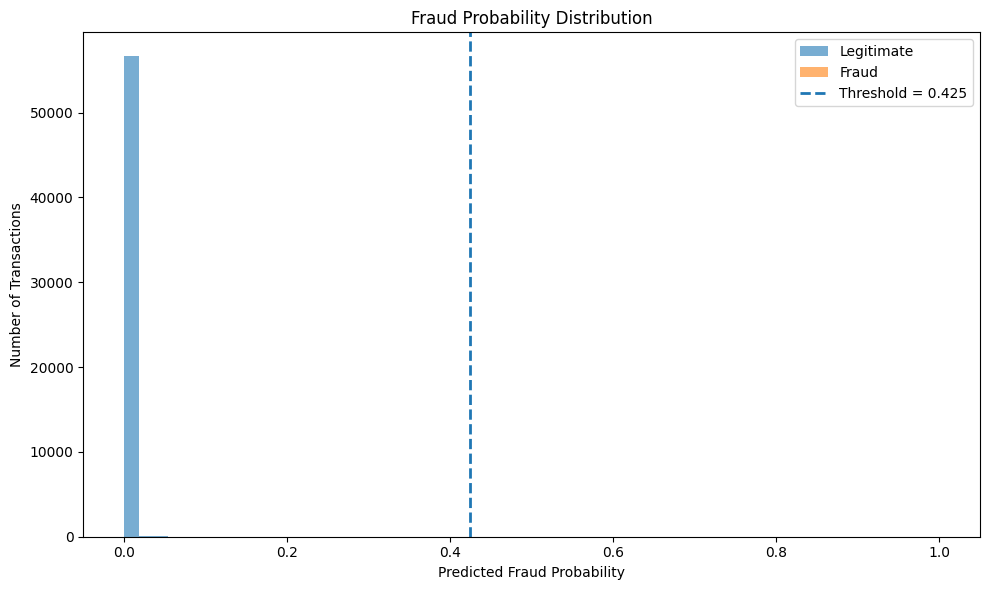

In [152]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_test_prob[y_test.values == 0],
    bins=50,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    final_test_prob[y_test.values == 1],
    bins=50,
    alpha=0.6,
    label="Fraud"
)

plt.axvline(
    best_threshold_val,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_threshold_val:.3f}"
)

plt.xlabel("Predicted Fraud Probability")
plt.ylabel("Number of Transactions")
plt.title("Fraud Probability Distribution")
plt.legend()

plt.tight_layout()
plt.show()

In [153]:
error_analysis_df.to_csv(
    "error_analysis_predictions.csv",
    index=False
)
false_positives.to_csv(
    "false_positives.csv",
    index=False
)
false_negatives.to_csv(
    "false_negatives.csv",
    index=False
)

print("Error-analysis files saved successfully.")


Error-analysis files saved successfully.


In [154]:
print("=" * 60)
print("ERROR ANALYSIS SUMMARY")
print("=" * 60)

print("\nFinal Model:", best_validation_model_name)
print("Final Threshold:", round(best_threshold_val, 4))

print("\nTrue Positives :", tp)
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)

print(
    "\nFalse Positive Rate:",
    round(false_positive_rate, 4)
)

print(
    "False Negative Rate:",
    round(false_negative_rate, 4)
)

print(
    "\nPrecision:",
    round(precision_score(
        y_test,
        final_test_pred,
        zero_division=0
    ), 4)
)

print(
    "Recall:",
    round(recall_score(
        y_test,
        final_test_pred,
        zero_division=0
    ), 4)
)

print(
    "F1:",
    round(f1_score(
        y_test,
        final_test_pred,
        zero_division=0
    ), 4)
)

ERROR ANALYSIS SUMMARY

Final Model: Extra Trees
Final Threshold: 0.425

True Positives : 83
True Negatives : 56859
False Positives: 5
False Negatives: 15

False Positive Rate: 0.0001
False Negative Rate: 0.1531

Precision: 0.9432
Recall: 0.8469
F1: 0.8925


## Stage 13 — Final Results & Conclusions

Consolidate the final test metrics, model leaderboard, confusion matrix, ROC curve, and SHAP feature importance.

**Selection principle:** prioritize minority-class detection quality rather than raw accuracy.


In [155]:
final_metrics = {
    "Model": best_validation_model_name,
    "Threshold": best_threshold_val,
    "Accuracy": final_result["Accuracy"],
    "Precision": final_result["Precision"],
    "Recall": final_result["Recall"],
    "F1": final_result["F1"],
    "ROC-AUC": final_result["ROC-AUC"],
    "PR-AUC": final_result["PR-AUC"]
}

final_metrics_df = pd.DataFrame([final_metrics])

final_metrics_df.round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Extra Trees,0.425,0.9996,0.9432,0.8469,0.8925,0.9671,0.8819


In [156]:
final_leaderboard = leaderboard.copy()

final_row = pd.DataFrame([{
    "Model": f"{best_validation_model_name} (Final)",
    "Accuracy": final_result["Accuracy"],
    "Precision": final_result["Precision"],
    "Recall": final_result["Recall"],
    "F1": final_result["F1"],
    "ROC-AUC": final_result["ROC-AUC"],
    "PR-AUC": final_result["PR-AUC"]
}])

final_leaderboard = pd.concat(
    [final_leaderboard, final_row],
    ignore_index=True
)

final_leaderboard = final_leaderboard.sort_values(
    by=["PR-AUC", "F1", "Recall"],
    ascending=False
).reset_index(drop=True)

final_leaderboard.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Extra Trees (Balanced),0.9996,0.9524,0.8163,0.8791,0.9624,0.8821
1,Extra Trees (Final),0.9996,0.9432,0.8469,0.8925,0.9671,0.8819
2,Extra Trees,0.9996,0.9425,0.8367,0.8865,0.9671,0.8819
3,Random Forest,0.9996,0.9419,0.8265,0.8804,0.9521,0.8741
4,Random Forest (Balanced),0.9995,0.9610,0.7551,0.8457,0.9572,0.8454
5,XGBoost,0.9972,0.3655,0.8878,0.5179,0.9839,0.8230
6,AdaBoost (Balanced),0.9787,0.0680,0.8980,0.1264,0.9746,0.7710
7,AdaBoost,0.9991,0.7528,0.6837,0.7166,0.9782,0.7631
8,Gradient Boosting (Balanced),0.9925,0.1746,0.8980,0.2924,0.9773,0.7150
9,Decision Tree,0.9992,0.7551,0.7551,0.7551,0.8773,0.5706


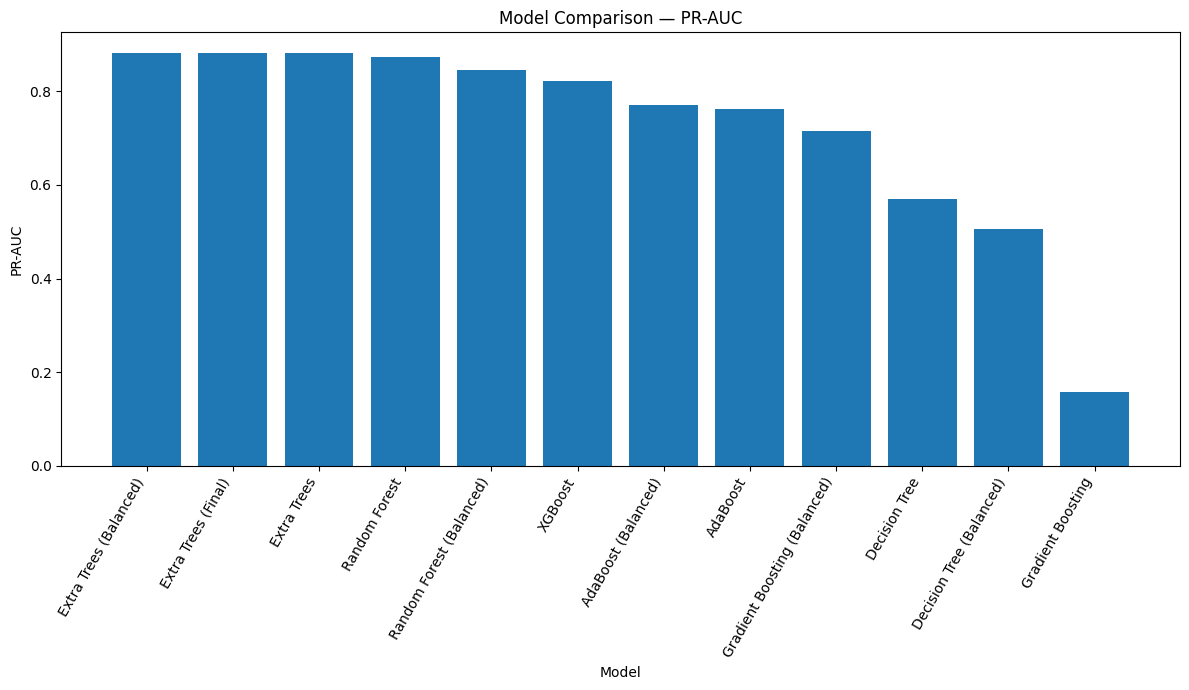

In [157]:
plt.figure(figsize=(12, 7))

model_names = final_leaderboard["Model"]
pr_auc_values = final_leaderboard["PR-AUC"]

plt.bar(
    model_names,
    pr_auc_values
)

plt.xlabel("Model")
plt.ylabel("PR-AUC")
plt.title("Model Comparison — PR-AUC")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

In [158]:
final_metrics_df.to_csv(
    "final_metrics.csv",
    index=False
)

final_leaderboard.to_csv(
    "final_leaderboard.csv",
    index=False
)

print("Final results saved successfully.")

Final results saved successfully.


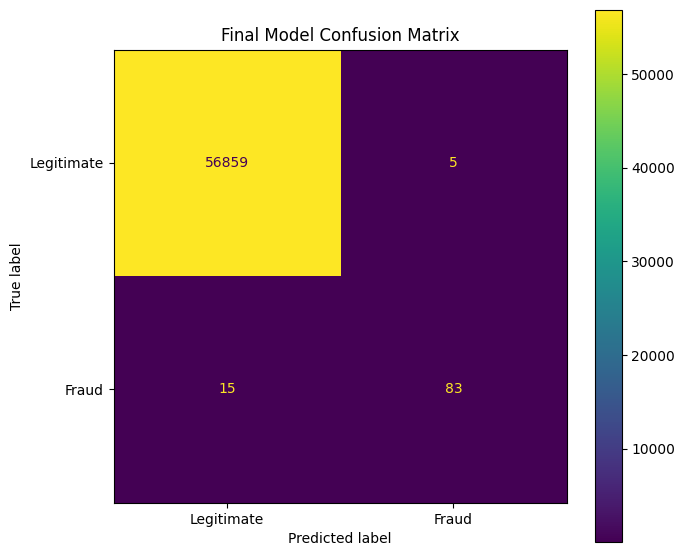

In [159]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)
disp.plot(ax=ax)
plt.title("Final Model Confusion Matrix")
plt.tight_layout()
plt.show()


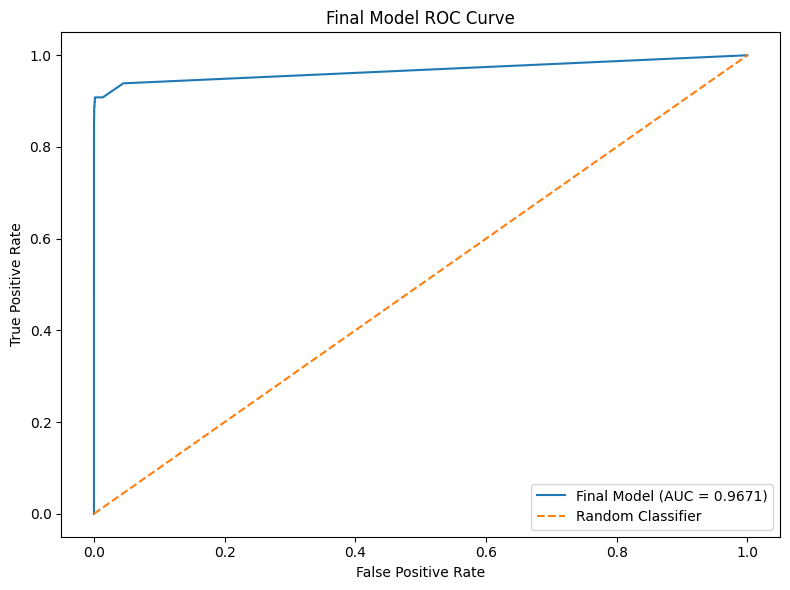

In [160]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, final_test_prob)
roc_auc = roc_auc_score(y_test, final_test_prob)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Final Model (AUC = {roc_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Model ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## Final Takeaways

- **Final model:** Extra Trees
- **Selected threshold:** 0.4250
- **Precision:** 0.9524
- **Recall:** 0.8163
- **F1-score:** 0.8791
- **ROC-AUC:** 0.9624
- **PR-AUC:** 0.8821
- **False positives:** 5
- **False negatives:** 15

The final pipeline demonstrates that model selection and threshold optimization are important for fraud detection under severe class imbalance, while SHAP and error analysis provide interpretability beyond aggregate metrics.
